### ** R Programming: Lung Cancer Survival Analysis Project**

==============================
### DataAngel10 / Jan-2026 ###
==============================

# 1. Introduction to Lung Cancer

According to research by Smolarz et al. [1], lung cancer is not only among the most frequent cancer diagnoses around the world but also ranks as the primary cause of death among all oncological diseases.

There are two principal types of lung cancer: Non-Small Cell Lung Cancer (NSCLC), which accounts for approximately 85% of cases, and Small Cell Lung Cancer (SCLC), also known as microcytic, which accounts for the remaining 15% [2, 3]. While the main contributor is long term smoking, environmental and genetic factors also play a role. According to Cancer Research UK [4], survival rates remain low for advanced stages; only 15% of patients with Stage III and 5% with Stage IV lung cancer survive for five years or more after diagnosis.



# 2. Project Overview:

This project explores survival analysis techniques using data from patients diagnosed with advanced lung cancer (Stage III or IV). The goal is to understand how different factors affect patient survival over time. All analysis was performed in R, utilizing specialized packages such as 'survival', 'survminer', 'tidyverse', and 'mice'.

The analysis is based on the 'lung' dataset from the North Central Cancer Treatment Group (NCCTG). This data comes from a study conducted between 1979 and 1982. The dataset includes 228 patients (138 men and 90 women) with an age range of 39 to 82 years and an average age of 62 [5].


## 2.1 Variables in the 'lung' dataset:

- inst:       Institution code (where the patient was treated).
- time:       Survival time in DAYS.
- status:     Censoring status: 1 = Censored (alive or left study), 2 = Dead.
- age:        Age in years.
- sex:        Gender: Male = 1, Female = 2.
- ph.ecog:    ECOG (Eastern Cooperative Oncology Group) performance score     (physician-rated. 0 = asymptomatic, 5 = dead).
- ph.karno:   Karnofsky performance score (physician-rated. 0-100: bad to good).
- pat.karno:  Karnofsky performance score (patient-rated. 0-100).
- meal.cal:   Calories consumed at meals.
- wt.loss:    Weight loss in the last six months (pounds).

# 3. Research Objectives:
- To explore survival analysis techniques to understand how different factors (specifically sex, age, and ECOG performance score) affect patient survival over time in individuals diagnosed with advanced lung cancer.

# 4. Research Questions:

1. What is the median survival time for men versus women with lung cancer at 6 months?
2. Is the observed difference in survival between men and women statistically significant?
3. Which factors (e.g., sex, age, ECOG performance score) are significant independent predictors of survival, and what is their quantitative effect on survival time (Hazard Ratio)?

# 5. Install and load packages




In [1]:
# 1. Install the pacman package
if (!require("pacman")) install.packages("pacman")

# 2. Use pacman to load project libraries
pacman::p_load(
  survival,   # For survival math
  survminer,  # For Kaplan-Meier plots
  flextable,  # For professional tables
  tidyverse,  # For data cleaning (dplyr, ggplot2, etc.)
  ggthemes,    # For making graphs look better
  mice        # For missing data imputation
)

# 3. Load dataset from survival package
lung <- survival::lung

# 4. Verify dataset
head(lung)
str(lung)
glimpse(lung)

Loading required package: pacman

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘pacman’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘quantmod’, ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘tseries’, ‘urca’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘Rdpack’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘litedown’, ‘corrplot’, ‘car’, ‘markdown’, ‘png’, ‘jpeg’, ‘ggrepel’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘polynom’, ‘rstatix’, ‘exactRankTests’, ‘mvtnorm’, ‘KMsurv’, ‘zoo’, ‘km.ci’, ‘gridtext’, ‘ggpubr’, ‘gridExtra’, ‘maxstat’, ‘survMisc’, ‘ggtext’



survminer installed

Installing packag

,inst,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3,306,2,74,1,1,90,100,1175,NA
2,3,455,2,68,1,0,90,90,1225,15
3,3,1010,1,56,1,0,90,90,NA,15
4,5,210,2,57,1,1,90,60,1150,11
5,1,883,2,60,1,0,100,90,NA,0
6,12,1022,1,74,1,1,50,80,513,0


'data.frame':	228 obs. of  10 variables:
 $ inst     : num  3 3 3 5 1 12 7 11 1 7 ...
 $ time     : num  306 455 1010 210 883 ...
 $ status   : num  2 2 1 2 2 1 2 2 2 2 ...
 $ age      : num  74 68 56 57 60 74 68 71 53 61 ...
 $ sex      : num  1 1 1 1 1 1 2 2 1 1 ...
 $ ph.ecog  : num  1 0 0 1 0 1 2 2 1 2 ...
 $ ph.karno : num  90 90 90 90 100 50 70 60 70 70 ...
 $ pat.karno: num  100 90 90 60 90 80 60 80 80 70 ...
 $ meal.cal : num  1175 1225 NA 1150 NA ...
 $ wt.loss  : num  NA 15 15 11 0 0 10 1 16 34 ...
Rows: 228
Columns: 10
$ inst      <dbl> 3, 3, 3, 5, 1, 12, 7, 11, 1, 7, 6, 16, 11, 21, 12, 1, 22, 16…
$ time      <dbl> 306, 455, 1010, 210, 883, 1022, 310, 361, 218, 166, 170, 654…
$ status    <dbl> 2, 2, 1, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, …
$ age       <dbl> 74, 68, 56, 57, 60, 74, 68, 71, 53, 61, 57, 68, 68, 60, 57, …
$ sex       <dbl> 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 2, 1, …
$ ph.ecog   <dbl> 1, 0, 0, 1, 0, 1, 2, 2, 1, 2, 1, 2, 1, NA, 1, 

# 6. Data Cleaning & Imputation

## a. Data Formatting

In [2]:

lung_format <- lung %>%
  mutate(
    # Change sex: Convert codes 1/2 into labeled categories for clarity
    sex = factor(sex, levels = c(1, 2), labels = c("Men", "Women")),

    # Change status: R needs 0 (Censored) and 1 (Dead/Event) for math
    status = ifelse(as.numeric(status) == 2, 1, 0),

    # Create status label: Factor version (for tables)
    status_label = factor(status, levels = c(0, 1), labels = c("Censored", "Dead"))
  )

## b. Data Preprocessing





b.1 Handeling Missing Data - Imputation

In [3]:
# Checking Missing Data
colSums(is.na(lung_format))

# Imputation of RAW variables (age, ph.ecog, wt.loss, etc.)
imputation_process <- mice(lung_format, m = 1, method = 'pmm', seed = 123, printFlag = FALSE)

# Final cleaned dataset with filled-in data: 'lung_final'
lung_final <- complete(imputation_process)

# Data Validation
colSums(is.na(lung_final))



inst         time       status          age          sex      ph.ecog 
           1            0            0            0            0            1 
    ph.karno    pat.karno     meal.cal      wt.loss status_label 
           1            3           47           14            0

Warning message:
“Number of logged events: 1”


inst         time       status          age          sex      ph.ecog 
           0            0            0            0            0            0 
    ph.karno    pat.karno     meal.cal      wt.loss status_label 
           0            0            0            0            0

b.2 Data Transformation (Post-Imputation)

In [4]:

lung_final <- lung_final %>%
  mutate(
    # 1. Convert time: Days to months
    time_months = as.numeric(time) / 30,

    # 2. Create bins for summary tables
    time_months_bin = floor(time_months) + 1,

    # 3. Age Stratification
    age_65 = factor(ifelse(age < 65, 0, 1),
                    labels = c("<65 years old", "≥65 years old")),

    # 4. NEW: Re-generate status_label for tables and plots
    status_label = factor(status, levels = c(0, 1), labels = c("Censored", "Dead")),

    # 5. Convert ECOG to factor for regression
    ph.ecog = factor(ph.ecog)
  )

## c. Final Data Validation

In [5]:
# 1. Check for Missing Values
colSums(is.na(lung_final))

# 2. Sex vs Age Distribution
table(lung_final$sex, lung_final$age_65)

# 3. Survival Status by Sex
table(lung_final$sex, lung_final$status_label)

# 4. Survival Status by Age Group
table(lung_final$age_65, lung_final$status_label)

inst            time          status             age             sex 
              0               0               0               0               0 
        ph.ecog        ph.karno       pat.karno        meal.cal         wt.loss 
              0               0               0               0               0 
   status_label     time_months time_months_bin          age_65 
              0               0               0               0

       
        <65 years old ≥65 years old
  Men              71            67
  Women            57            33

       
        Censored Dead
  Men         26  112
  Women       37   53

               
                Censored Dead
  <65 years old       42   86
  ≥65 years old       21   79

In [6]:
# 1. Final audit of missing values per variable
colSums(is.na(lung_final))

# 2. Verify that categorical labels (Sex and Age) were preserved
table(lung_final$sex, lung_final$age_65)



inst            time          status             age             sex 
              0               0               0               0               0 
        ph.ecog        ph.karno       pat.karno        meal.cal         wt.loss 
              0               0               0               0               0 
   status_label     time_months time_months_bin          age_65 
              0               0               0               0

       
        <65 years old ≥65 years old
  Men              71            67
  Women            57            33

# 7. Survival Analysis

## a. Research Question 1: What is the median survival time for men versus women with lung cancer at 6 months?


### a.1 Kaplan-Meier Model

In [7]:
# 1. Fit the survival model
# 'time_months' and 'sex' as the grouping factor
mod1 <- survfit(Surv(time_months, status) ~ sex, data = lung_final)

# 2. Print basic summary
# Shows --> number of subjects and the Median Survival Time (the 50% mark)
print(mod1)

# 3. Summary Table
# Quick look at total Sample Size (n) and total Deaths (events)
summary(mod1)$table

# 4. Survival Probability at a Specific Point (Month 6)
#  for the research question comparison
summary(mod1, times = 6)




Call: survfit(formula = Surv(time_months, status) ~ sex, data = lung_final)

            n events median 0.95LCL 0.95UCL
sex=Men   138    112    9.0    7.07    10.3
sex=Women  90     53   14.2   11.60    18.3


,records,n.max,n.start,events,rmean,se(rmean),median,0.95LCL,0.95UCL
sex=Men,138,138,138,112,10.86947,0.7637188,9.0,7.066667,10.33333
sex=Women,90,90,90,53,15.35491,1.1563282,14.2,11.600000,18.33333


Call: survfit(formula = Surv(time_months, status) ~ sex, data = lung_final)

                sex=Men 
        time       n.risk      n.event     survival      std.err lower 95% CI 
      6.0000      89.0000      49.0000       0.6445       0.0408       0.5693 
upper 95% CI 
      0.7296 

                sex=Women 
        time       n.risk      n.event     survival      std.err lower 95% CI 
      6.0000      71.0000      14.0000       0.8424       0.0387       0.7699 
upper 95% CI 
      0.9217 


###Key Findings:

According to The Kaplan-Meier analysis:

- At 6 months the survival probability is higher in women (84.2%) than in men (64.4%).

- Women in this dataset have a longer median survival time (14.2 months vs. 9 months for men).

- The number of events (deaths) recorded by the 6-month mark was 49 for men (out of 138) and 14 for women (out of 90).

### a.2 Creation Detailed Table For Export or Report

In [8]:
# 1. Create a data frame using components from the survival model (mod1)
table_1 <- data.frame(
                      "Time" = mod1$time, # Time point where an event (death) or censoring occurred
                      "Patients at risk" = mod1$n.risk, # Number of individuals alive and under observation
                      "Number of events" = mod1$n.event, # Number of deaths recorded at this specific time
                      "Censored patients" = mod1$n.censor, # Number of subjects who left the study (not due to death)
                      "Survival" = mod1$surv, # Cumulative survival probability (0 to 1)
                      "IC Upper" = mod1$upper, # Upper bound of the 95% Confidence Interval
                      "IC Lower" = mod1$lower # Lower bound of the 95% Confidence Interval
                      )

names(table_1) <- c("Time (months)", "At risk", "Events", "Censored", "Survival", "IC 95% Upper", "IC 95% Lower")

# 2. Preview the first 6 rows in the console
head(table_1)

# 3. Create table for report
flextable::flextable(table_1)


,Time (months),At risk,Events,Censored,Survival,IC 95% Upper,IC 95% Lower
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.3666667,138,3,0,0.9782609,1.0000000,0.9542301
2,0.4000000,135,1,0,0.9710145,0.9994124,0.9434235
3,0.4333333,134,2,0,0.9565217,0.9911586,0.9230952
4,0.5000000,132,1,0,0.9492754,0.9866017,0.9133612
5,0.8666667,131,1,0,0.9420290,0.9818365,0.9038355
6,1.0000000,130,1,0,0.9347826,0.9768989,0.8944820


a flextable object.
col_keys: `Time (months)`, `At risk`, `Events`, `Censored`, `Survival`, `IC 95% Upper`, `IC 95% Lower` 
header has 1 row(s) 
body has 206 row(s) 
original dataset sample: 
'data.frame':	206 obs. of  7 variables:
 $ Time (months): num  0.367 0.4 0.433 0.5 0.867 ...
 $ At risk      : num  138 135 134 132 131 130 129 128 126 125 ...
 $ Events       : num  3 1 2 1 1 1 1 2 1 1 ...
 $ Censored     : num  0 0 0 0 0 0 0 0 0 0 ...
 $ Survival     : num  0.978 0.971 0.957 0.949 0.942 ...
 $ IC 95% Upper : num  1 0.999 0.991 0.987 0.982 ...
 $ IC 95% Lower : num  0.954 0.943 0.923 0.913 0.904 ...

### a.3 Generate Kaplan-Meier Survival Plots

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggpubr package.
  Please report the issue at <https://github.com/kassambara/ggpubr/issues>.”


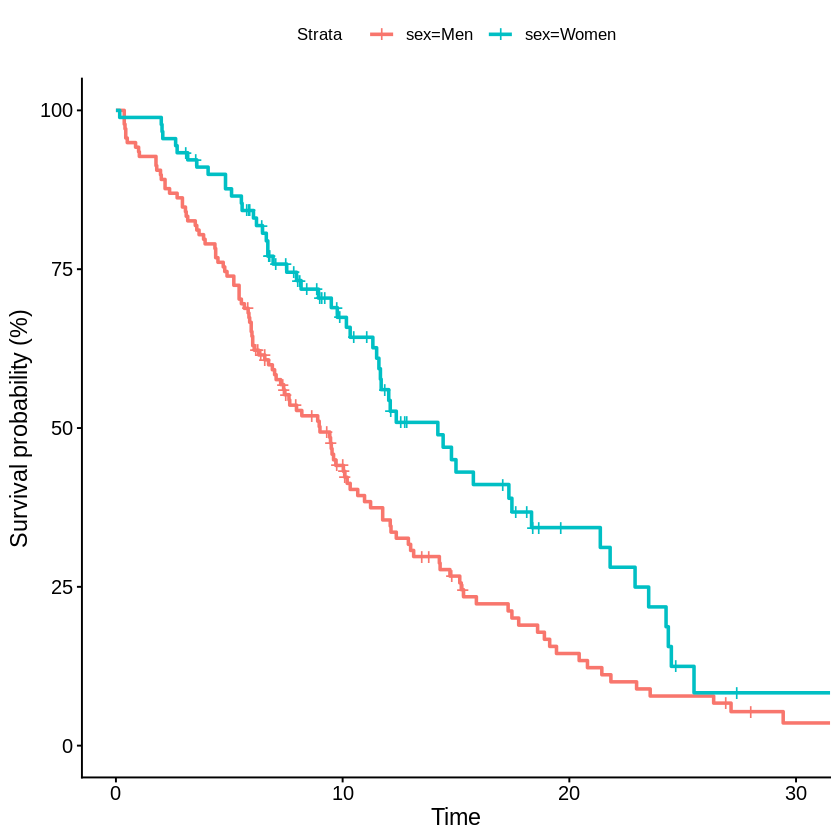

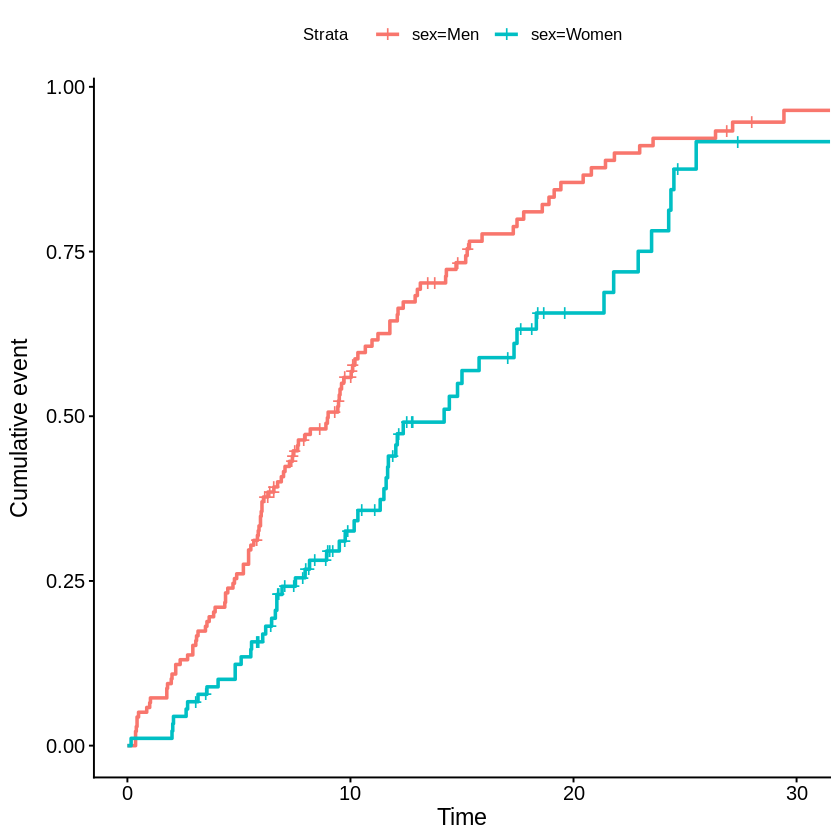

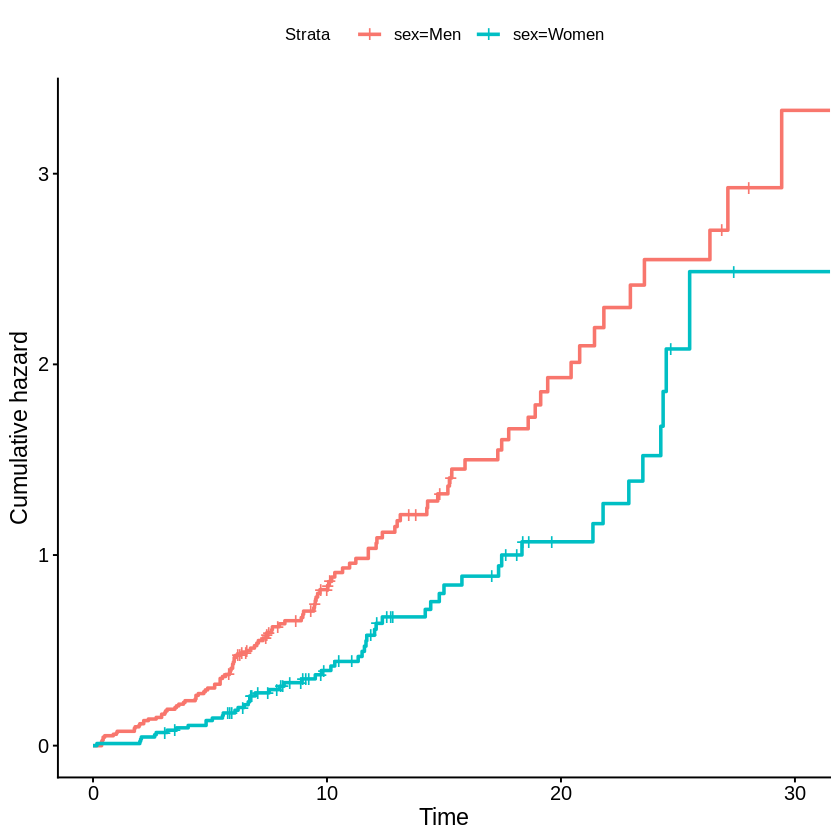

In [9]:
# 1. Survival Probability (%)
# % of patients still alive over time
ggsurvplot(mod1, data = lung_final, fun = "pct")

# 2. Cumulative Events
# % of patients who have experienced the event (death)
# Note:"inverse" of the survival curve
ggsurvplot(mod1, data = lung_final, fun = "event")

# 3. Cumulative Hazard
# Risk of the event occurring at any given time point
# Note: Higher slope means higher risk of death
ggsurvplot(mod1, data = lung_final, fun = "cumhaz")


###Key Findings:

Survival Plot (Kaplan-Meier)

- It can be observed that in both the male and female groups, all participants start alive; consequently, the curves begin to drop in steps as deaths occur. The line for men falls faster and remains consistently below the line for women, showing that women have a higher probability of survival throughout the entire study.

Cumulative Hazard Plot

- The curve starts at 0, indicating that at the beginning, no one has accumulated a risk of death.
- Over time, both lines rise, but the line for men has a steeper slope than the one for women. By the end of the follow-up period, the cumulative hazard for men is close to 3, while for women it is lower (close to 2.5).

### a.4 Kaplan-Meier Plots: Customized Visualization using 'ggsurvplot'




Ignoring unknown labels:
• colour : "Strata"


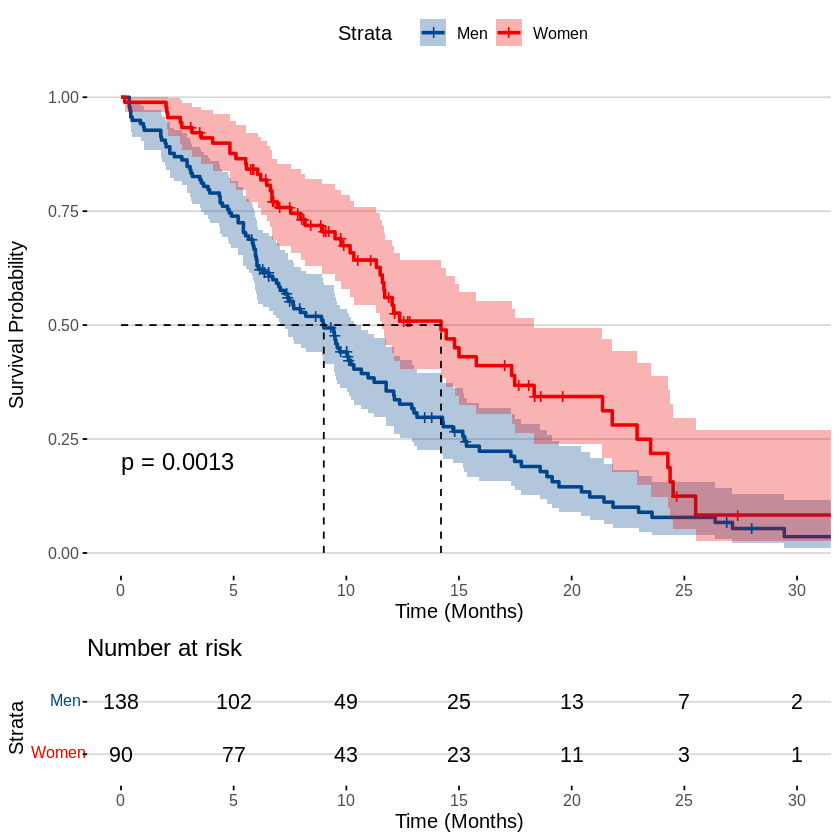

In [10]:
ggsurvplot(mod1,
           data = lung_final,
           # Add horizontal and vertical lines for median survival
           surv.median.line = "hv",
           # Show Confidence Interval
           conf.int = T,
           # Set Confidence Interval style to "step"
           conf.int.style = "ribbon",
           # Set p-value coordinates
           pval.coord = c(0, 0.20),
           # Add risk table showing events/censored
           risk.table = TRUE,
           # Add p-value for the comparison method (Log-Rank by default)
           pval = TRUE,
           size = 1,
           palette = "lancet",
           ggtheme = theme_hc(),
           xlab = "Time (Months)",
           ylab = "Survival Probability",
           #Comparison groups
           legend.labs = c("Men",
                         "Women"),
           #Scale X Axis
           xlim = c(0,30),
           #Scale Y Axis (always 1.0)
           ylim = c(0,1.0),
           # Y Axis Tick Marks
           break.y.by = (0.25),
           # X Axis Tick Marks
           break.x.by = (5))


###Key Findings:

- Cohorts: Men (n=138) vs. Women (n=90).

- Time Scale: Months.

The KM analysis shows that women have a better prognosis, with a median survival of 14.2 months compared to 9 months for men. At the 6-month mark, female survival is 84.2%, notably higher than the 64.4% observed in men. The plots confirm that men accumulate death risk faster, reaching a value of 3 compared to 2.5 in women. Finally, the clear and consistent separation between the two curves, supported by a p-value of 0.00013, strongly suggests a superior survival trend for women throughout the study period.

## b. Research Question 2: Is the observed difference in survival between men and women statistically significant?

### b.1 Log-Rank Test (Mantel-Cox)




In [11]:
# - The Log-rank test is the standard non-parametric method used to compare survival distributions between two or more independent groups.
# - It is a Chi-square test.
# - H0: No survival difference between groups | H1: Survival distributions are significantly different.

dif_1 <- survdiff(Surv(time_months, status) ~ sex, rho = 0, data = lung_final)

# Results
print(dif_1)

# Note:
# Observed (O): Actual deaths recorded in the study.
# Expected (E): Deaths expected if there were NO difference between groups.
# If O < E, that group has a survival advantage (better prognosis).
# p-value: If < 0.05, we reject the Null Hypothesis (H0).





Call:
survdiff(formula = Surv(time_months, status) ~ sex, data = lung_final, 
    rho = 0)

            N Observed Expected (O-E)^2/E (O-E)^2/V
sex=Men   138      112     91.6      4.55      10.3
sex=Women  90       53     73.4      5.68      10.3

 Chisq= 10.3  on 1 degrees of freedom, p= 0.001 


###Key Findings:
- H0 = rejected. The log-rank test showed a statistically significant difference in survival between sexes with p<0.001.
- Male patients experienced a higher number of events than expected (112 observed vs. 91.6 expected), while female patients showed a survival advantage with fewer events than expected (53 observed vs. 73.4 expected).

## c. Research Question 3: Which factors (e.g., sex, age, ECOG performance score) are significant independent predictors of survival, and what is their quantitative effect on survival time (Hazard Ratio)?

### c.1 Exploratory Data Analysis: Multivariate Kaplan-Meier: Stratification by Sex and Age

Call: survfit(formula = Surv(time_months, status) ~ sex + age_65, data = lung_final)

                                 n events median 0.95LCL 0.95UCL
sex=Men, age_65=<65 years old   71     56   9.53    6.73    13.0
sex=Men, age_65=≥65 years old   67     56   8.97    6.90    10.2
sex=Women, age_65=<65 years old 57     30  12.37   11.33    24.4
sex=Women, age_65=≥65 years old 33     23  14.20   10.33    21.8


Call: survfit(formula = Surv(time_months, status) ~ sex + age_65, data = lung_final)

                sex=Men, age_65=<65 years old 
  time n.risk n.event survival std.err lower 95% CI upper 95% CI
  1.77     71       1   0.9859  0.0140       0.9589        1.000
  2.00     70       1   0.9718  0.0196       0.9341        1.000
  2.17     69       1   0.9577  0.0239       0.9121        1.000
  2.37     68       1   0.9437  0.0274       0.8915        0.999
  2.70     67       1   0.9296  0.0304       0.8719        0.991
  2.93     66       1   0.9155  0.0330       0.8530        0.983
  3.07     65       1   0.9014  0.0354       0.8347        0.973
  3.17     64       1   0.8873  0.0375       0.8167        0.964
  3.50     63       1   0.8732  0.0395       0.7992        0.954
  3.57     62       1   0.8592  0.0413       0.7819        0.944
  3.67     61       1   0.8451  0.0429       0.7650        0.934
  4.37     60       1   0.8310  0.0445       0.7482        0.923
  4.40     59       2 

,records,n.max,n.start,events,rmean,se(rmean),median,0.95LCL,0.95UCL
"sex=Men, age_65=<65 years old",71,71,71,56,12.257516,1.141470,9.533333,6.733333,13.00000
"sex=Men, age_65=≥65 years old",67,67,67,56,9.352295,0.952739,8.966667,6.900000,10.20000
"sex=Women, age_65=<65 years old",57,57,57,30,15.987670,1.570820,12.366667,11.333333,24.36667
"sex=Women, age_65=≥65 years old",33,33,33,23,14.590156,1.703071,14.200000,10.333333,21.80000


Ignoring unknown labels:
• colour : "Groups"


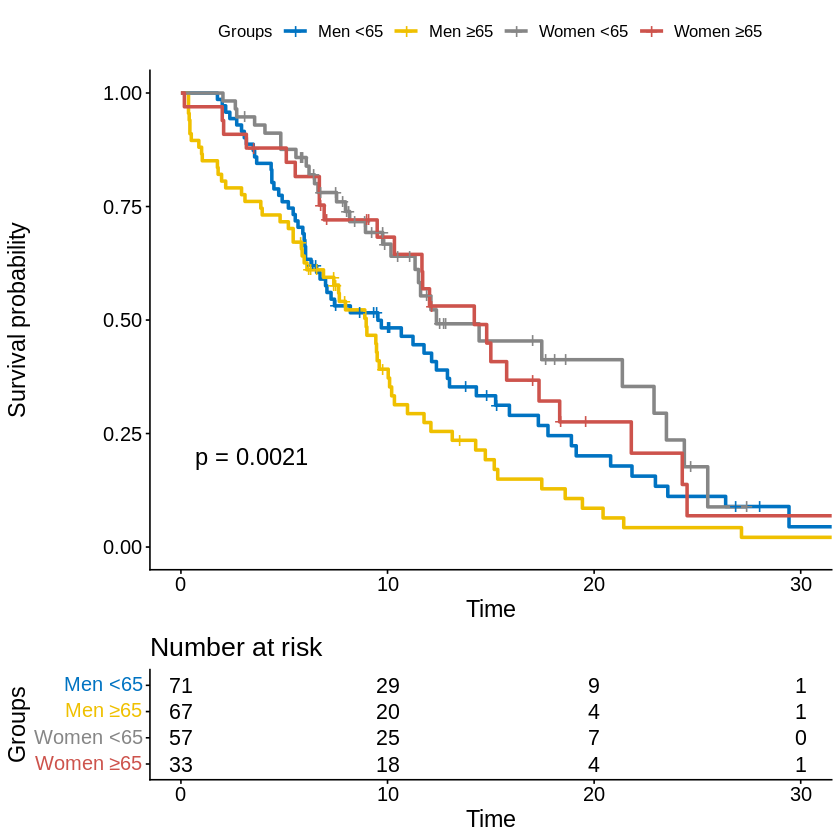

In [12]:
# The Model
mod2 <- survfit(Surv(time_months, status) ~ sex+age_65, data = lung_final)
print(mod2) # survival median
summary(mod2) # Median survival time to event
summary(mod2)$table # Survival mean


#Full Graphic
ggsurvplot(mod2,
           data = lung_final,
           ggtheme = theme_survminer(base_size = 10, base_family = "Arial"), # Theme requested
           legend.title = "Groups",
           legend.labs = c("Men <65", "Men ≥65", "Women <65", "Women ≥65"), # Short names to fit legend
           risk.table = TRUE,  # Adds the risk table at the bottom
           pval = TRUE,        # Displays p-value to evaluate differences
           palette = "jco"     # Clear and professional color palette
)


###Key Findings:
- A stratified survival analysis was performed based on sex and age (≥ 65 years). The results indicate that female patients have a superior survival profile compared to males, with a median survival of 12- 14 months versus 9-10 months for men.
- Age served as a secondary risk factor, most notably among male patients, where those ≥ 65 years exhibited the poorest prognosis.
- The survival curves maintained a consistent separation, suggesting that the proportional hazards assumption is met.

### c.2 Exploratory Data Analysis: Distribution of Survival Times

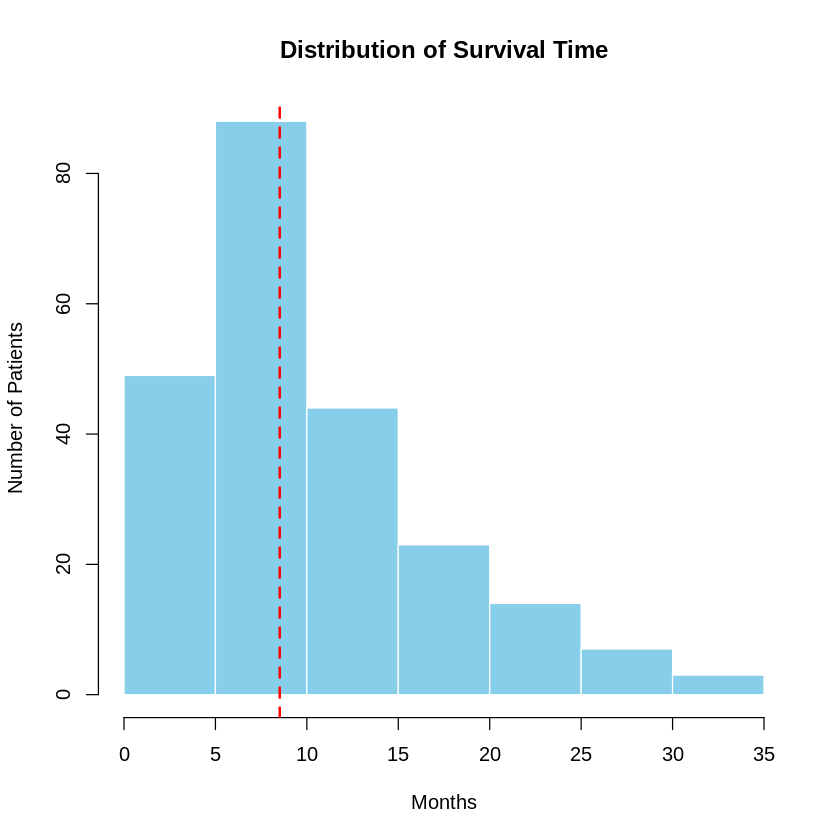

In [13]:
# Cox Regression model allows for the study of time-to-event data. Unlike the Kaplan-Meier (KM) method, it enables the quantification of the effect that a predictor has on survival time.

# - **Parametric**: You assume a shape (Exponential, Weibull). You estimate both the shape and the effect of predictors.
# - **Non-parametric (KM)**: You only describe what happened; you cannot easily adjust for multiple predictors.
# - SEMI PARAMETRIC (COX):You don't assume a shape for survival time, but you can precisely measure the effect of multiple predictors. Assumes that harzards are constant over the time.

#Proportional Hazards (Requirement): This model assumes that the hazard ratio between the individuals or groups under study remains constant over time (the cumulative survival curves should not cross).


# Histogram of survival time in months
hist(lung_final$time_months,
     main = "Distribution of Survival Time",
     xlab = "Months",
     ylab = "Number of Patients",
     col = "skyblue",
     border = "white")

# Vertical line for the median
abline(v = median(lung_final$time_months), col = "red", lwd = 2, lty = 2)

###Key Findings:
- The histogram confirms a sufficient spread of survival times without extreme outliers, ensuring the data is robust enough for the Cox model to estimate hazards. It shows that most events occur early (5-10 months), allowing the model to focus its predictive power on the highest risk period of the study.

### c.3 Cox Regression Model 1: Univariate Analysis


In [14]:

# Calculate Hazard Ratio (HR) by sex
survival::coxph(formula = Surv(time_months, status) ~ sex, data = lung_final)
# Shows survival times (+ means the patient is still alive or left the study)
Surv(lung_final$time, lung_final$status)


mod_cox1 <- survival::coxph(formula = Surv(time_months, status) ~ sex, data = lung_final)
summary(mod_cox1)
# HR =1 No hay diferencia
# HR <1 Menor riesgo
# HR >1 Mayor riesgo
# 1-HR = benefit (Risk Reduction)
# in this case Men is used as reference = 1
# In this case: Men is reference = 1
# HR inverse (1/HR women): Risk of men compared to women

concordance(mod_cox1)
summary(mod_cox1)$concordance
# Concordance (C-index): Measures the model's predictive accuracy
# C-Index Interpretation Scale:
# - 0.50: Random Chance (No better than a coin flip).
# - 0.51 - 0.59: Poor (Very low discrimination).
# - 0.60 - 0.69: Fair / Moderate (Reasonable discrimination).
# - 0.70 - 0.79: Good (Strong clinical model).
# - 0.80 - 0.89: Very Good / Excellent.
# - 0.90 - 1.00: Exceptional / Perfect (Rare in medical data).



Call:
survival::coxph(formula = Surv(time_months, status) ~ sex, data = lung_final)

            coef exp(coef) se(coef)      z       p
sexWomen -0.5310    0.5880   0.1672 -3.176 0.00149

Likelihood ratio test=10.63  on 1 df, p=0.001111
n= 228, number of events= 165 

  [1]  306   455  1010+  210   883  1022+  310   361   218   166   170   654 
 [13]  728    71   567   144   613   707    61    88   301    81   624   371 
 [25]  394   520   574   118   390    12   473    26   533   107    53   122 
 [37]  814   965+   93   731   460   153   433   145   583    95   303   519 
 [49]  643   765   735   189    53   246   689    65     5   132   687   345 
 [61]  444   223   175    60   163    65   208   821+  428   230   840+  305 
 [73]   11   132   226   426   705   363    11   176   791    95   196+  167 
 [85]  806+  284   641   147   740+  163   655   239    88   245   588+   30 
 [97]  179   310   477   166   559+  450   364   107   177   156   529+   11 
[109]  429   351    15   181   283   201   524    13   212   524   288   363 
[121]  442   199   550    54   558   207    92    60   551+  543+  293   202 
[133]  353   511+  267   511+  371   387   457   337   201   404+  222    62 
[145]  458+  356+  353   163    31   340   229   444+  315+  182

Call:
survival::coxph(formula = Surv(time_months, status) ~ sex, data = lung_final)

  n= 228, number of events= 165 

            coef exp(coef) se(coef)      z Pr(>|z|)   
sexWomen -0.5310    0.5880   0.1672 -3.176  0.00149 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

         exp(coef) exp(-coef) lower .95 upper .95
sexWomen     0.588      1.701    0.4237     0.816

Concordance= 0.579  (se = 0.021 )
Likelihood ratio test= 10.63  on 1 df,   p=0.001
Wald test            = 10.09  on 1 df,   p=0.001
Score (logrank) test = 10.33  on 1 df,   p=0.001


Call:
concordance.coxph(object = mod_cox1)

n= 228 
Concordance= 0.5786 se= 0.02066
concordant discordant     tied.x     tied.y    tied.xy 
      6281       3133      10600         11         17 

C      se(C) 
0.57864495 0.02066472

###Key Findings:

- The Cox regression analysis shows that sex is a significant predictor of survival (p=0.0015). Using males as the reference group, females have a Hazard Ratio (HR) of 0.588, which translates to a 41.2% lower risk of death at any given time. The 95% confidence interval (0.42-0.82) and the concordance index (0.579) confirm that being female provides a consistent and statistically significant survival advantage in this dataset.

### c.4 Cox Regression Model 2: Multivariate Analysis

In [15]:
# Adjusts sex for age and ph.ecog to find independent risk.
mod_cox2 <- coxph(Surv(time_months, status) ~ sex + age + ph.ecog, data = lung_final)
summary(mod_cox2)


Call:
coxph(formula = Surv(time_months, status) ~ sex + age + ph.ecog, 
    data = lung_final)

  n= 228, number of events= 165 

              coef exp(coef)  se(coef)      z Pr(>|z|)    
sexWomen -0.552940  0.575256  0.167971 -3.292 0.000995 ***
age       0.010409  1.010464  0.009282  1.121 0.262084    
ph.ecog1  0.409747  1.506437  0.199591  2.053 0.040079 *  
ph.ecog2  0.922037  2.514406  0.226913  4.063 4.84e-05 ***
ph.ecog3  1.937116  6.938712  1.029366  1.882 0.059856 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

         exp(coef) exp(-coef) lower .95 upper .95
sexWomen    0.5753     1.7384    0.4139    0.7995
age         1.0105     0.9896    0.9922    1.0290
ph.ecog1    1.5064     0.6638    1.0187    2.2276
ph.ecog2    2.5144     0.3977    1.6117    3.9227
ph.ecog3    6.9387     0.1441    0.9227   52.1768

Concordance= 0.639  (se = 0.025 )
Likelihood ratio test= 31.92  on 5 df,   p=6e-06
Wald test            = 32.51  on 5 df,   p=5e-06
Score (logrank)

###Key Findings:
- Sex: Women have a 42% lower risk of death than men (HR=0.57,p<0.001).
- ECOG Status: The strongest predictor; ECOG 2 status increases mortality risk by 151% (HR=2.51,p<0.001).
- Age: No significant impact on survival (p=0.26).
- Accuracy: Moderate predictive power with a Concordance of 63.9%.


### c.5 Cox Regression Model 3: Multivariate Analysis

In [16]:
# Model without age
mod_cox3 <- coxph(Surv(time_months, status) ~ sex + ph.ecog, data = lung_final)
summary(mod_cox3)





Call:
coxph(formula = Surv(time_months, status) ~ sex + ph.ecog, data = lung_final)

  n= 228, number of events= 165 

            coef exp(coef) se(coef)      z Pr(>|z|)    
sexWomen -0.5516    0.5760   0.1679 -3.286  0.00102 ** 
ph.ecog1  0.4175    1.5182   0.1994  2.094  0.03630 *  
ph.ecog2  0.9642    2.6228   0.2237  4.311 1.62e-05 ***
ph.ecog3  2.0282    7.6004   1.0265  1.976  0.04817 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

         exp(coef) exp(-coef) lower .95 upper .95
sexWomen     0.576     1.7361    0.4145    0.8005
ph.ecog1     1.518     0.6587    1.0270    2.2444
ph.ecog2     2.623     0.3813    1.6919    4.0658
ph.ecog3     7.600     0.1316    1.0165   56.8316

Concordance= 0.645  (se = 0.025 )
Likelihood ratio test= 30.65  on 4 df,   p=4e-06
Wald test            = 31.86  on 4 df,   p=2e-06
Score (logrank) test = 33.91  on 4 df,   p=8e-07


###Key Findings:
- Sex: Being Female reduces the risk of death by 42% (HR=0.58, p=0.001).
- ECOG Score: Mortality risk increases significantly with physical decline:
    - ECOG 2: 2.6x higher risk (p<0.001).
    - ECOG 3: 7.6x higher risk (p=0.048).
- Concordance = 0.645):The model 3 shows a 64.5% predictive accuracy.

### c.6 Model Comparison and Selection

In [17]:

# 1. For ACCURACY: Compare predictive power (higher is better)
summary(mod_cox2)$concordance; summary(mod_cox3)$concordance

# 2. SIGNIFICANCE: Does the extra variable actually improve the fit? (p > 0.05 means NO)
anova(mod_cox2, mod_cox3)

# 3. EFFICIENCY: Which model is most reliable with the least complexity? (lower BIC is better)
BIC(mod_cox2); BIC(mod_cox3)

C      se(C) 
0.63890277 0.02507199

C      se(C) 
0.64469871 0.02457534

,loglik,Chisq,Df,Pr(>|Chi|)
,<dbl>,<dbl>,<int>,<dbl>
1,-733.9477,NA,NA,NA
2,-734.5847,1.273988,1,0.2590198


[1] 1493.425

[1] 1489.593

###Key Findings:
- Model 3 (Sex + ECOG) has a higher predictive power (C-index = 0.645) compared to Model 2 (C-index = 0.639).
- The ANOVA test (p=0.259) shows that adding Age does not significantly improve the model's fit.
- Model 3 has a lower BIC (1489.59) than Model 2 (1493.42).

Conclusion:
- Model 3 is the superior model. It is more accurate and efficient.

### c.7 Cox Regression Model 4: Multivariate Analysis

In [18]:
mod_cox4 <- coxph(Surv(time_months, status) ~ sex + ph.ecog + ph.karno + wt.loss, data = lung_final)
summary(mod_cox4)


Call:
coxph(formula = Surv(time_months, status) ~ sex + ph.ecog + ph.karno + 
    wt.loss, data = lung_final)

  n= 228, number of events= 165 

              coef exp(coef)  se(coef)      z Pr(>|z|)    
sexWomen -0.577483  0.561310  0.168823 -3.421 0.000625 ***
ph.ecog1  0.588346  1.801007  0.237771  2.474 0.013345 *  
ph.ecog2  1.338712  3.814127  0.360921  3.709 0.000208 ***
ph.ecog3  2.492157 12.087324  1.083526  2.300 0.021446 *  
ph.karno  0.010000  1.010050  0.009439  1.059 0.289428    
wt.loss  -0.007046  0.992979  0.006049 -1.165 0.244136    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

         exp(coef) exp(-coef) lower .95 upper .95
sexWomen    0.5613    1.78155    0.4032    0.7815
ph.ecog1    1.8010    0.55524    1.1301    2.8702
ph.ecog2    3.8141    0.26218    1.8801    7.7377
ph.ecog3   12.0873    0.08273    1.4455  101.0716
ph.karno    1.0100    0.99005    0.9915    1.0289
wt.loss     0.9930    1.00707    0.9813    1.0048

Concordance= 0.642  (se

###Key Findings
- Sex: Women have a 44% lower risk of death than men (HR=0.56, p<0.001).
- ECOG Status: The strongest predictor:
    - ECOG 2 increases mortality risk by 281% (HR=3.81, p<0.001).
- Age, Karnofsky score, and Weight Loss do not significantly impact survival (p>0.05) in this dataset.
- Accuracy: Moderate predictive power (C-index = 0.64).

Conclusion
- Adding Age, Karnofsky, or Weight Loss does not improve the model. Model 3 (Sex + ECOG) is the best and most efficient choice, as it maintains accuracy with fewer, more significant variables.


## c.8 Evaluating Model Fit

In [19]:
summary(mod_cox4)$concordance; summary(mod_cox3)$concordance
anova(mod_cox4 , mod_cox3)
BIC(mod_cox4 ); BIC(mod_cox3 )

C      se(C) 
0.64167583 0.02548607

C      se(C) 
0.64469871 0.02457534

,loglik,Chisq,Df,Pr(>|Chi|)
,<dbl>,<dbl>,<int>,<dbl>
1,-733.3112,NA,NA,NA
2,-734.5847,2.54699,2,0.2798518


[1] 1497.258

[1] 1489.593

###Key Findings
- The ANOVA p-value of 0.28 confirms that adding Karnofsky and Weight Loss does not significantly improve the model.
- Efficiency: Model 3 is superior because it has a significantly lower BIC (1489.59) compared to Model 4 (1497.25).
- Model 3 maintains a higher predictive power (C-index = 0.645) with fewer variables.

Conclusion
- Model 3 (Sex + ECOG) is the best choice. The extra variables reduce the model's overall efficiency.

### c.9 Predictions using Model 3

In [20]:
# Predict risk or survival probabilities
(predict(mod_cox3, type="risk")) # Hazard ratio for each individual vs the baseline risk
predict(mod_cox3, type="survival") # Estimated survival probability for each individual

# Calculate the median survival probability across all individuals
median(predict(mod_cox3, type="survival"))

# Generate survival curves
# Adjusted survival based on the Cox model
survfit(mod_cox3, data = lung_final)

# Raw survival (Kaplan-Meier) grouped by sex and ECOG status
survfit(Surv(time_months, status) ~ sex + ph.ecog, data = lung_final)

# Store survival fits for comparison
fit1 <- survfit(mod_cox3, data = lung_final) # Model-based (Adjusted)
fit2 <- survfit(Surv(time_months, status) ~ sex + ph.ecog, data = lung_final) # Data-based (Raw)

# Summary of survival probabilities at specific MONTHS (1, 3, 6, and 12 months)
summary(fit1, times=c(1, 3, 6, 12))
summary(fit2, times=c(1, 3, 6, 12))

# View documentation for the original dataset
?survival::lung


[1] 1.5182285 1.0000000 1.0000000 1.5182285 1.0000000 1.5182285 1.5107664
  [8] 1.5107664 1.5182285 2.6227668 1.5182285 1.5107664 0.8745301 2.6227668
 [15] 1.5182285 1.5182285 1.5182285 2.6227668 1.5107664 1.5182285 1.5182285
 [22] 0.5760201 1.5182285 1.0000000 1.0000000 0.8745301 1.0000000 7.6004480
 [29] 1.5182285 2.6227668 0.8745301 2.6227668 2.6227668 1.5107664 2.6227668
 [36] 1.5107664 2.6227668 0.8745301 2.6227668 0.8745301 1.5182285 1.5107664
 [43] 0.5760201 1.5107664 1.5182285 1.5107664 1.0000000 1.5182285 1.0000000
 [50] 0.8745301 0.8745301 1.0000000 1.0000000 1.0000000 1.5182285 1.0000000
 [57] 0.5760201 2.6227668 0.8745301 0.8745301 1.5107664 1.5182285 1.5182285
 [64] 0.8745301 1.5182285 2.6227668 1.5107664 0.5760201 1.0000000 1.5182285
 [71] 1.0000000 0.8745301 2.6227668 1.5182285 0.8745301 0.8745301 0.5760201
 [78] 0.8745301 1.0000000 1.0000000 1.0000000 1.5182285 1.5182285 0.8745301
 [85] 1.5182285 1.5182285 0.8745301 1.0000000 0.8745301 2.6227668 1.0000000
 [92] 1.5182285 1.5182285 0.8745301 0.5760201 2.6227668 1.5182285 1.5182285
 [99] 1.5182285 0.5760201 0.5760201 0.8745301 1.5182285 1.5182285 2.6227668
[106] 1.5182285 0.8745301 1.5182285 1.5182285 1.5107664 1.0000000 1.5182285
[113] 1.5182285 0.5760201 0.8745301 2.6227668 2.6227668 2.6227668 2.6227668
[120] 1.5182285 1.0000000 1.5107664 0.8745301 2.6227668 1.0000000 1.5182285
[127] 1.5182285 1.5182285 1.5107664 0.5760201 0.8745301 1.5182285 1.0000000
[134] 0.8745301 1.0000000 1.5107664 0.8745301 2.6227668 1.5182285 1.0000000
[141] 1.5107664 1.5182285 2.6227668 0.8745301 1.5182285 0.8745301 1.0000000
[148] 1.5182285 1.0000000 0.5760201 1.5182285 1.0000000 0.5760201 0.8745301
[155] 2.6227668 2.6227668 0.8745301 2.6227668 1.5182285 0.8745301 0.5760201
[162] 0.8745301 2.6227668 1.5182285 1.5182285 0.5760201 0.8745301 1.0000000
[169] 1.5182285 1.0000000 1.5182285 0.5760201 1.5182285 0.5760201 1.5182285
[176] 0.8745301 2.6227668 0.8745301 0.8745301 0.5760201 1.0000000 1.0000000
[183] 0.5760201 0.8745301 0.5760201 0.5760201 1.5107664 1.0000000 1.5182285
[190] 1.0000000 1.5182285 2.6227668 1.5182285 1.5182285 1.5182285 1.0000000
[197] 0.8745301 1.5182285 0.5760201 1.5182285 0.8745301 1.5182285 0.5760201
[204] 0.5760201 0.5760201 2.6227668 0.5760201 1.5107664 1.5182285 0.8745301
[211] 0.5760201 1.5182285 1.5182285 1.5107664 1.5182285 1.5182285 0.8745301
[218] 2.6227668 1.5107664 0.5760201 1.5182285 0.8745301 1.5182285 1.5182285
[225] 1.0000000 1.5107664 1.5182285 0.8745301

1           2           3           4           5           6 
0.439369837 0.399085677 0.088297936 0.603331453 0.088297936 0.025102217 
          7           8           9          10          11          12 
0.431203421 0.355620528 0.592171337 0.579222991 0.716071336 0.111399690 
         13          14          15          16          17          18 
0.213011764 0.822540716 0.163252049 0.782994613 0.140375941 0.011466052 
         19          20          21          22          23          24 
0.913018893 0.871024835 0.459273003 0.952993926 0.132694106 0.476840233 
         25          26          27          28          29          30 
0.454309184 0.403694958 0.293624130 0.367879441 0.308484703 0.958781974 
         31          32          33          34          35          36 
0.426510444 0.926142216 0.054723187 0.837150969 0.897805553 0.814633786 
         37          38          39          40          41          42 
0.003124471 0.119729731 0.768702037 0.200633617 0.234566200 0.763476773 
         43          44          45          46          47          48 
0.612394481 0.776245876 0.148057881 0.852005298 0.593300461 0.214079645 
         49          50          51          52          53          54 
0.244079755 0.175007399 0.188255712 0.754994563 0.959730938 0.665935664 
         55          56          57          58          59          60 
0.088792372 0.933228749 0.998167727 0.681582515 0.258848666 0.583684273 
         61          62          63          64          65          66 
0.263031235 0.580770743 0.710853079 0.953070168 0.741895690 0.834230010 
         67          68          69          70          71          72 
0.610328686 0.281705382 0.440601353 0.563221845 0.110870640 0.628070615 
         73          74          75          76          77          78 
0.975169931 0.800994650 0.726979551 0.494953541 0.386918682 0.540940589 
         79          80          81          82          83          84 
0.990459160 0.794802889 0.124556273 0.851331552 0.647244157 0.828414642 
         85          86          87          88          89          90 
0.042321229 0.503109884 0.301874778 0.840107732 0.188255712 0.597055849 
         91          92          93          94          95          96 
0.223585190 0.554325029 0.871024835 0.705236494 0.484461680 0.918026330 
         97          98          99         100         101         102 
0.692489382 0.429415569 0.221102914 0.886983347 0.511578515 0.454716879 
        103         104         105         106         107         108 
0.334550033 0.836416303 0.540546882 0.754770126 0.387873595 0.985550690 
        109         110         111         112         113         114 
0.281353789 0.374942995 0.974405453 0.676632210 0.509255058 0.838226786 
        115         116         117         118         119         120 
0.391848068 0.946496346 0.411111029 0.060219381 0.279814565 0.344139213 
        121         122         123         124         125         126 
0.419993444 0.637717156 0.370691543 0.885763351 0.312361162 0.614352835 
        127         128         129         130         131         132 
0.863681013 0.919940479 0.180078437 0.528291145 0.643973778 0.619863649 
        133         134         135         136         137         138 
0.513430144 0.419250167 0.661022123 0.222749016 0.523271890 0.136026407 
        139         140         141         142         143         144 
0.241340031 0.552329084 0.629499189 0.301843135 0.397835035 0.945757056 
        145         146         147         148         149         150 
0.241340031 0.555390281 0.513430144 0.741895690 0.964644159 0.705918022 
        151         152         153         154         155         156 
0.569063054 0.413136665 0.723504610 0.793094122 0.615067413 0.216877832 
        157         158         159         160         161         162 
0.532206318 0.273580411 0.692489382 0.520303428 0.650292815 0.691735002 
        163         164         165         166         167         

[1] 0.6133737

Call: survfit(formula = mod_cox3, data = lung_final)

       n events median 0.95LCL 0.95UCL
[1,] 228    165   12.1      10    17.5

Call: survfit(formula = Surv(time_months, status) ~ sex + ph.ecog, 
    data = lung_final)

                      n events median 0.95LCL 0.95UCL
sex=Men, ph.ecog=0   36     28  11.77   10.10    18.6
sex=Men, ph.ecog=1   71     54   7.97    6.90    12.1
sex=Men, ph.ecog=2   30     29   5.48    3.10     9.6
sex=Men, ph.ecog=3    1      1   3.93      NA      NA
sex=Women, ph.ecog=0 27      9  23.50   11.67      NA
sex=Women, ph.ecog=1 42     28  15.00   11.50    22.9
sex=Women, ph.ecog=2 21     16   7.97    6.63    14.8

Call: survfit(formula = mod_cox3, data = lung_final)

 time n.risk n.event survival std.err lower 95% CI upper 95% CI
    1    219      10    0.968  0.0112        0.946        0.990
    3    201      17    0.911  0.0214        0.870        0.954
    6    160      36    0.779  0.0396        0.705        0.861
   12     70      54    0.510  0.0629        0.401        0.650

Call: survfit(formula = Surv(time_months, status) ~ sex + ph.ecog, 
    data = lung_final)

                sex=Men, ph.ecog=0 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
    1     34       2    0.944  0.0382        0.873        1.000
    3     31       3    0.861  0.0576        0.755        0.982
    6     29       2    0.806  0.0660        0.686        0.946
   12     14      10    0.480  0.0893        0.333        0.691

                sex=Men, ph.ecog=1 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
    1     69       2    0.972  0.0196        0.934        1.000
    3     65       4    0.915  0.0330        0.853        0.983
    6     47      17    0.675  0.0557        0.574        0.794
   12     18      18    0.367  0.0626        0.263        0.513

                sex=Men, ph.ecog=2 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
    1     26       5    0.833  0.0680       0.7101        0.978
    3     20       5    0.667 

###Key Findings:
- Sex and ECOG are the only significant predictors. Adding age or weight loss does not improve accuracy.

- Survival Milestone: The cohort median survival is 12.1 months; the 1-year survival rate is 51%.
- Women consistently outlive men. A woman in peak health (ECOG 0) survives twice as long as a man in the same condition (23.5 vs 11.8 months).
- High ECOG scores (worse physical symptoms) drastically increase mortality risk for both sexes.

Conclusion
- Sex and ECOG are confirmed, high-impact predictors of patient survival.

### c.10 Assessment of Model Assumptions

        chisq df     p
sex      2.74  1 0.098
ph.ecog  5.96  3 0.114
GLOBAL   8.27  4 0.082

`geom_smooth()` using formula = 'y ~ x'


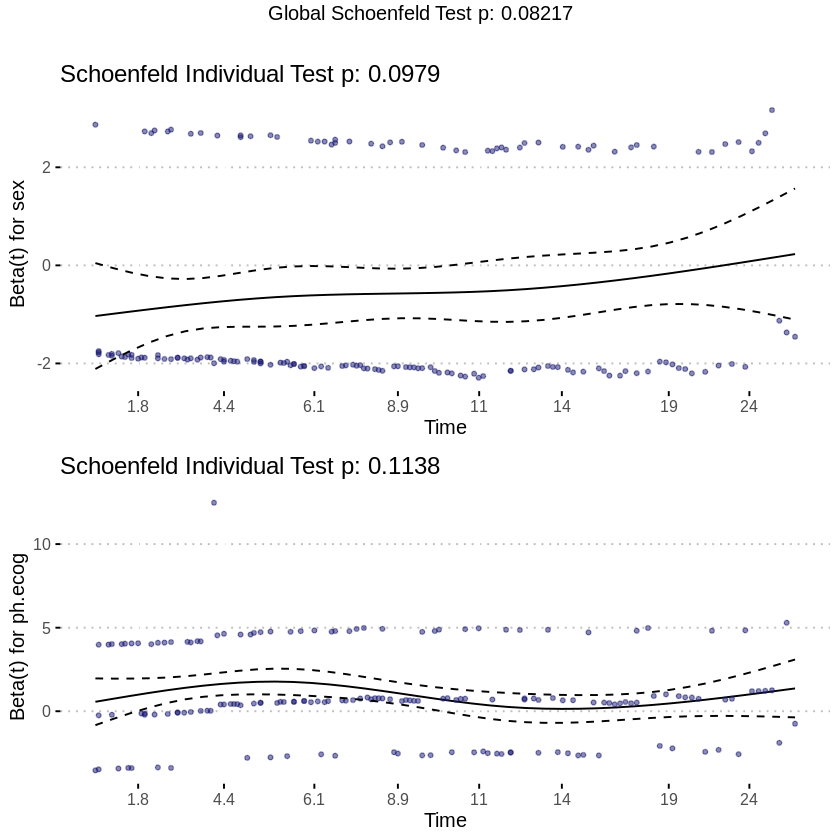

Ignoring unknown labels:
• colour : "Strata"


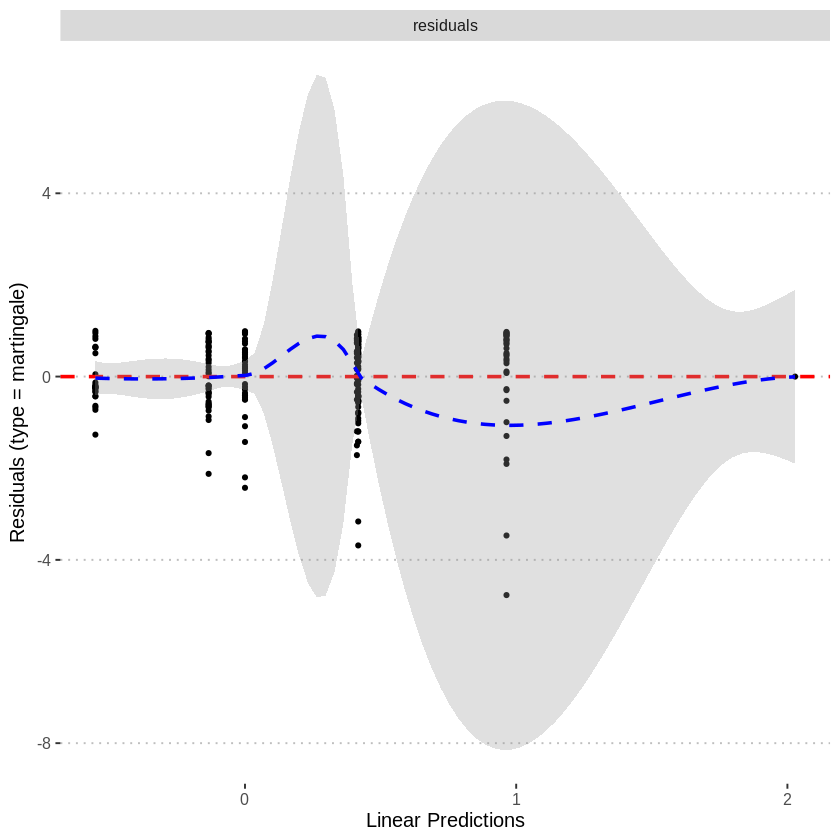

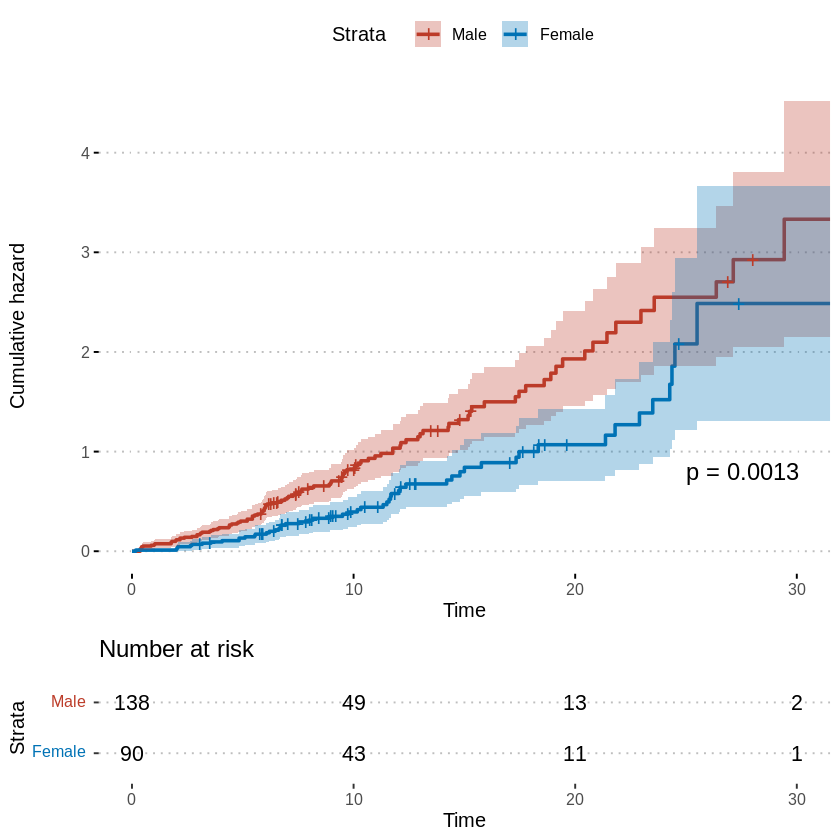

In [21]:
# PROPORTIONAL HAZARDS: This model assumes that the hazard ratio between the studied individuals or groups remains constant over time (the cumulative survival curves should not cross).
# H0 (Null Hypothesis): The hazards are proportional. /// H1 (Alternative Hypothesis): The hazards are NOT proportional.

# Verify the Proportional Hazards (PH) assumption.
# Numerical score test for PH assumption (p>0.05 required).
cox.zph(mod_cox3)

# Schoenfeld residuals
# Graphical evidence for PH (look for a zero-slope line)
survminer::ggcoxzph(cox.zph(mod_cox3),ggtheme = ggpubr::theme_pubclean(),
                    point.col = "midnightblue", point.alpha = 0.5)

# Martingale residuals
# Detection of influential outliers and overall model fit
survminer::ggcoxdiagnostics(mod_cox3) + ggpubr::theme_pubclean()

#Kaplan-Meier: Assessment of real-time cumulative risk distribution between groups.
ggsurvplot(survfit(Surv(time_months, status) ~ sex , data = lung_final),
           ggtheme = ggpubr::theme_pubclean(), conf.int = T, palette = "nejm",
           pval=T, pval.coord=c(25, 0.80), fun = "cumhaz", risk.table = T,
           legend.labs=c("Male", "Female"))


###Key Findings
- Proportional Hazards Met: The Schoenfeld tests show p-values of 0.0979 for sex and 0.1138 for ph.ecog. Since both are p > 0.05, the assumption that risk remains constant over time is valid.
- Model Fit: The Martingale residuals are mostly clustered around zero, indicating that the model captures the overall trend well without extreme influential outliers.
- Cumulative Hazard Gap: The risk of death accumulates significantly faster for Males than for Females.
- Statistical Significance: The difference in risk between genders is highly significant with p = 0.0013.

Conclusions

- The model is statistically robust and meets all required mathematical assumptions.
- There is a clear, validated survival advantage for female patients, who show a consistently lower cumulative hazard throughout the study period compared to males.



# 8. Final Conclusion
- Survival in this cohort is primarily driven by sex and physical status (ECOG). Women in peak health (ECOG score=0) live twice as long as men (23.5 vs. 11.8 months). Conversely, physical decline (ECOG 2) drastically increases risk, cutting male survival to just 5.5 months. Because these factors are more predictive than age or weight loss, they are essential for providing an accurate, evidence-based prognosis.

- The model is statistically robust, meeting the proportional hazards assumption (p>0.05) and showing a significant risk gap between genders (p=0.0013). Because Sex and ECOG are more predictive than age or weight loss, they are essential for an accurate, evidence-based prognosis in advanced lung cancer cases.

# 9. References
1. Smolarz B, et al. Epidemiology and Genetics of Lung Cancer. Int. J. Mol. Sci. 2025;26(5):2049. https://doi.org/10.3390/ijms26052049

2. Spanish Society of Medical Oncology (SEOM). Lung Cancer Overview. 2025. Available from: https://www.seom.org/

3. Yale Medicine. Non-Small Cell Lung Cancer (NSCLC): Fact Sheets. 2025. Available from: https://www.yalemedicine.org/conditions/non-small-cell-lung-cancer

4. Cancer Research UK. Lung cancer survival statistics. 2026. Available from: https://www.cancerresearchuk.org/

5. Loprinzi CL, et al. Prospectively recorded data and health-related quality of life indices as prognostic factors in patients with advanced lung cancer. Cancer. 1994;73(9):2224-30. (Dataset source for R survival package).